<a href="https://colab.research.google.com/github/amscally-dsci/Data-Science-Cohort-20/blob/main/Project-5/Project5_DRAFT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Natural Language Processing



This project will give you practical experience using Natural Language Processing techniques. This project is in three parts:
- in part 1) you will use a dataset in a CSV file
- in part 2) you will use the Wikipedia API to directly access content
on Wikipedia.
- in part 3) you will make your notebook interactive


### Imports

In [1]:
%%capture output
#install Wikipedia API
!pip3 install wikipedia-api


In [2]:
import numpy as np
import pandas as pd
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.neighbors import NearestNeighbors

pd.options.display.max_columns = 100

import nltk
# nltk.download('omw-1.4')
nltk.download('punkt_tab')
# nltk.download('averaged_perceptron_tagger_eng')

import wikipediaapi


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [3]:
%%capture
!python -m textblob.download_corpora


In [4]:
df=pd.read_csv('https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv')
df

,URI,name,text
0,<http://dbpedia.org/resource/Digby_Morrell>,Digby Morrell,digby morrell born 10 october 1979 is a former...
1,<http://dbpedia.org/resource/Alfred_J._Lewy>,Alfred J. Lewy,alfred j lewy aka sandy lewy graduated from un...
2,<http://dbpedia.org/resource/Harpdog_Brown>,Harpdog Brown,harpdog brown is a singer and harmonica player...
3,<http://dbpedia.org/resource/Franz_Rottensteiner>,Franz Rottensteiner,franz rottensteiner born in waidmannsfeld lowe...
4,<http://dbpedia.org/resource/G-Enka>,G-Enka,henry krvits born 30 december 1974 in tallinn ...
...,...,...,...
42781,<http://dbpedia.org/resource/Motoaki_Takenouchi>,Motoaki Takenouchi,motoaki takenouchi born july 8 1967 saitama pr...
42782,<http://dbpedia.org/resource/Alan_Judge_(footb...,"Alan Judge (footballer, born 1960)",alan graham judge born 14 may 1960 is a retire...
42783,<http://dbpedia.org/resource/Eduardo_Lara>,Eduardo Lara,eduardo lara lozano born 4 september 1959 in c...
42784,<http://dbpedia.org/resource/Tatiana_Faberg%C3...,Tatiana Faberg%C3%A9,tatiana faberg is an author and faberg scholar...


### Part 1)



- The CSV file is available at https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv
- The file contains a list of famous people and a brief overview.
- The goal of part 1) is to ...
  1. Pick one person from the list ( the reference person ) and output 10 other people who's overview are "closest" to the reference person in a Natural Language Processing sense
  1. Also output the sentiment of the overview of the reference person



1. Pick one person from the list ( the reference person )

In [5]:
# Target Reference Person john bryson chane
# Enter index number in [] to select person
person_index=42379
person=df.iloc[person_index]
person

,42379
URI,<http://dbpedia.org/resource/John_Bryson_Chane>
name,John Bryson Chane
text,john bryson chane born may 13 1944 is a bishop...


In [6]:
# Exception example for Present
# Enter index number in [] to select person
person_index_exception=16491
person_exception_df=df.iloc[person_index_exception]
person_exception_df

,16491
URI,<http://dbpedia.org/resource/John_Rose_(organi...
name,John Rose (organist)
text,john rose is an american concert organist who ...


2. output 10 other people who's overview are "closest" to the reference person in a Natural Language Processing sense

## TF IDF

In [7]:
# Perform the TF-IDF transformation - Option 2 (CountVectorizer + TfidfTransformer - better for large datasets)
tf_idf_tran = TfidfVectorizer()
tf_idf = tf_idf_tran.fit_transform(df['text'])
tf_idf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 7417853 stored elements and shape (42786, 437503)>

### KNN

#### Fit Nearest Neighbors

In [8]:
nn = NearestNeighbors(n_neighbors=11)

In [9]:
nn.fit(tf_idf)

NearestNeighbors(n_neighbors=11)

Create the reference matrix from the tf_idf matrix


In [10]:
sent0 = tf_idf[person_index]
sent0.shape


(1, 437503)

In [11]:
distances, indices = nn.kneighbors(
  X = sent0,
  n_neighbors = 11,
)


In [12]:
print(distances,indices)

[[0.         1.1323916  1.14457298 1.15643428 1.15969597 1.16143514
  1.16986702 1.17232416 1.17518256 1.17645065 1.17747081]] [[42379 34444 20379 25389 11746 33858  2610 25795  6145 29067 16491]]


In [13]:
names = [df['name'][idx] for idx in indices]


In [14]:
# 10 nearest neighbors to person_index
print(names)

[42379         John Bryson Chane
34444             Chris Chivers
20379    Colin Johnson (bishop)
25389       Frederick H. Borsch
11746      Tony Burton (bishop)
33858       Stephen H. Bancroft
2610                 Roger Ames
25795          Robert V. Taylor
6145            Benjamin Nzimbi
29067           Stephen Smalley
16491      John Rose (organist)
Name: name, dtype: object]


In [15]:
ten_nndf=pd.DataFrame(names)
ten_nndf

ten_nndf=ten_nndf.transpose()
ten_nndf
print(distances)

ten_nndf['distances']=distances[0]
ten_nndf


[[0.         1.1323916  1.14457298 1.15643428 1.15969597 1.16143514
  1.16986702 1.17232416 1.17518256 1.17645065 1.17747081]]


,name,distances
42379,John Bryson Chane,0.000000
34444,Chris Chivers,1.132392
20379,Colin Johnson (bishop),1.144573
25389,Frederick H. Borsch,1.156434
11746,Tony Burton (bishop),1.159696
33858,Stephen H. Bancroft,1.161435
2610,Roger Ames,1.169867
25795,Robert V. Taylor,1.172324
6145,Benjamin Nzimbi,1.175183
29067,Stephen Smalley,1.176451


3. Also output the sentiment of the overview of the reference person

In [16]:
person_overview=df.at[person_index,'text']
person_overview

'john bryson chane born may 13 1944 is a bishop in the episcopal church he was the eighth diocesan bishop of washington he was elected on the second ballot and was consecrated on june 1 2002 in his capacity as bishop he also served as interim dean of the washington national cathedral while it searched for a new dean he was president and ceo of the protestant episcopal cathedral foundation which oversees the operations of the washington national cathedral and the three cathedral schools of saint albans the national cathedral school for girls and beauvoir schoolhe was named by washingtonian magazine as one of the 150 most influential leaders in the district of columbia and recognized by the london telegraph as one of the 50 most prominent leaders in the anglican communiona leader in global interfaith dialogue and study he has traveled to iran on numerous occasions as the invited guest of former president sayyed mohammad khatami in late 2011 he was part of a four person delegation that tr

In [17]:
person_blob=TextBlob(person_overview)
person_blob.sentiment

Sentiment(polarity=0.047835497835497835, subjectivity=0.3044913419913419)

### Part 2)



- For the same reference person that you chose in Part 1), use the Wikipedia API to access the whole content of the reference person's Wikipedia page.
- The goal of Part 2) is to ...
  1. Print out the text of the Wikipedia article for the reference person
  1. Determine the sentiment of the text of the Wikipedia page for the reference person
  1. Collect the text of the Wikipedia pages from the 10 nearest neighbors from Part 1)
  1. Determine the nearness ranking of these 10 people to your reference person based on their entire Wikipedia page
  1. Compare, i.e. plot,  the nearest ranking from Step 1) with the Wikipedia page nearness ranking.  A difference of the rank is one means of comparison.



Install Wikipedia API

In [18]:
%%capture
!pip3 install wikipedia-api


In [19]:
import wikipediaapi


Pull out page from Wikipedia


In [20]:
# https://en.wikipedia.org/wiki/JohnBrysonChane
topic = 'John Bryson Chane'
wikip = wikipediaapi.Wikipedia('foobar')
page_ex = wikip.page(topic)
wiki_text = page_ex.text
wiki_text


'John Bryson Chane (born May 13, 1944) is a retired bishop of the Episcopal Church. The eighth diocesan bishop of Washington, he was consecrated at Washington National Cathedral on June 1, 2002, leading the Episcopal Diocese of Washington until he retired in November 2011. During this time, he also served between June 2003 and April 2005 as interim dean of Washington National Cathedral. In his role as Bishop of Washington, Chane served as president and CEO of the Protestant Episcopal Cathedral Foundation, which oversees the operations of Washington National Cathedral and the three cathedral schools: St. Alban\'s School for Boys, the National Cathedral School for Girls, and Beauvoir, the National Cathedral Elementary School.\nWashingtonian Magazine named him as one of the 150 most influential leaders in the District of Columbia. The Sunday Telegraph in London called him one of the most prominent leaders in the Anglican Communion.\nA leader in global interfaith dialogue and study, Chane 

Replace newline chars with spaces before doing any processing. Strip the ' and "s" from possessives.


In [21]:
wiki_text_clean = (
  wiki_text
  .lower()
  .replace("\n"," ")
  .replace("\'s",'')
  .replace('\'','')
  .replace("(", "")
  .replace(")", "")
  .replace('"', "")
)
wiki_text_clean


'john bryson chane born may 13, 1944 is a retired bishop of the episcopal church. the eighth diocesan bishop of washington, he was consecrated at washington national cathedral on june 1, 2002, leading the episcopal diocese of washington until he retired in november 2011. during this time, he also served between june 2003 and april 2005 as interim dean of washington national cathedral. in his role as bishop of washington, chane served as president and ceo of the protestant episcopal cathedral foundation, which oversees the operations of washington national cathedral and the three cathedral schools: st. alban school for boys, the national cathedral school for girls, and beauvoir, the national cathedral elementary school. washingtonian magazine named him as one of the 150 most influential leaders in the district of columbia. the sunday telegraph in london called him one of the most prominent leaders in the anglican communion. a leader in global interfaith dialogue and study, chane travele

Convert to textblob

In [22]:
wiki_blob = TextBlob(wiki_text_clean)
wiki_blob

TextBlob("john bryson chane born may 13, 1944 is a retired bishop of the episcopal church. the eighth diocesan bishop of washington, he was consecrated at washington national cathedral on june 1, 2002, leading the episcopal diocese of washington until he retired in november 2011. during this time, he also served between june 2003 and april 2005 as interim dean of washington national cathedral. in his role as bishop of washington, chane served as president and ceo of the protestant episcopal cathedral foundation, which oversees the operations of washington national cathedral and the three cathedral schools: st. alban school for boys, the national cathedral school for girls, and beauvoir, the national cathedral elementary school. washingtonian magazine named him as one of the 150 most influential leaders in the district of columbia. the sunday telegraph in london called him one of the most prominent leaders in the anglican communion. a leader in global interfaith dialogue and study, chan

In [23]:
wiki_blob.sentiment

Sentiment(polarity=0.10318299271787644, subjectivity=0.36943857176415323)

3. Collect the text of the Wikipedia pages from the 10 nearest neighbors from Part 1)

4. Determine the nearness ranking of these 10 people to your reference person based on their entire Wikipedia page

5. Compare, i.e. plot, the nearest ranking from Step 1) with the Wikipedia page nearness ranking. A difference of the rank is one means of comparison.

In [24]:
basewiki_link='https://en.wikipedia.org/wiki/'

In [25]:
names_list=list(names[0])

In [26]:
wiki_list=[basewiki_link + name.replace(' ','_') for name in names_list]
wiki_list



['https://en.wikipedia.org/wiki/John_Bryson_Chane',
 'https://en.wikipedia.org/wiki/Chris_Chivers',
 'https://en.wikipedia.org/wiki/Colin_Johnson_(bishop)',
 'https://en.wikipedia.org/wiki/Frederick_H._Borsch',
 'https://en.wikipedia.org/wiki/Tony_Burton_(bishop)',
 'https://en.wikipedia.org/wiki/Stephen_H._Bancroft',
 'https://en.wikipedia.org/wiki/Roger_Ames',
 'https://en.wikipedia.org/wiki/Robert_V._Taylor',
 'https://en.wikipedia.org/wiki/Benjamin_Nzimbi',
 'https://en.wikipedia.org/wiki/Stephen_Smalley',
 'https://en.wikipedia.org/wiki/John_Rose_(organist)']

In [27]:
#topic = 'John Bryson Chane'
#wikip = wikipediaapi.Wikipedia('foobar')
#page_ex = wikip.page(topic)
#wiki_text = page_ex.text

In [28]:
def getpage(topic):
  '''Calls up wikipedia page text for reference person. '''
  person = topic
  wikip = wikipediaapi.Wikipedia('foobar')
  page_ex = wikip.page(topic)
  wiki_text = page_ex.text
  return wiki_text

In [29]:
wiki_text_list=[]
for name in names_list:
  text=getpage(name)
  wiki_text_list.append(text)


In [30]:
# Wikipedia web page text for refernce person (all 11)
wiki_text_list

['John Bryson Chane (born May 13, 1944) is a retired bishop of the Episcopal Church. The eighth diocesan bishop of Washington, he was consecrated at Washington National Cathedral on June 1, 2002, leading the Episcopal Diocese of Washington until he retired in November 2011. During this time, he also served between June 2003 and April 2005 as interim dean of Washington National Cathedral. In his role as Bishop of Washington, Chane served as president and CEO of the Protestant Episcopal Cathedral Foundation, which oversees the operations of Washington National Cathedral and the three cathedral schools: St. Alban\'s School for Boys, the National Cathedral School for Girls, and Beauvoir, the National Cathedral Elementary School.\nWashingtonian Magazine named him as one of the 150 most influential leaders in the District of Columbia. The Sunday Telegraph in London called him one of the most prominent leaders in the Anglican Communion.\nA leader in global interfaith dialogue and study, Chane

In [31]:
len(wiki_text_list)

11

In [32]:
# repeat wiki text clean from above but for all 11 wiki text pages.
def wiki_text_cleaning(wiki_text):

  wiki_text_clean = (
    wiki_text
    .lower()
    .replace("\n"," ")
    .replace("\'s",'')
    .replace('\'','')
    .replace("(", "")
    .replace(")", "")
    .replace('"', "")
  )
  return wiki_text_clean


In [33]:
wiki_text_cleaned_list=[]
for i in wiki_text_list:
  clean=wiki_text_cleaning(i)
  wiki_text_cleaned_list.append(clean)


In [34]:
wiki_text_cleaned_list

['john bryson chane born may 13, 1944 is a retired bishop of the episcopal church. the eighth diocesan bishop of washington, he was consecrated at washington national cathedral on june 1, 2002, leading the episcopal diocese of washington until he retired in november 2011. during this time, he also served between june 2003 and april 2005 as interim dean of washington national cathedral. in his role as bishop of washington, chane served as president and ceo of the protestant episcopal cathedral foundation, which oversees the operations of washington national cathedral and the three cathedral schools: st. alban school for boys, the national cathedral school for girls, and beauvoir, the national cathedral elementary school. washingtonian magazine named him as one of the 150 most influential leaders in the district of columbia. the sunday telegraph in london called him one of the most prominent leaders in the anglican communion. a leader in global interfaith dialogue and study, chane travel

In [35]:
len(wiki_text_cleaned_list)

11

In [36]:
wiki_df=pd.DataFrame(names).transpose()
wiki_df

wiki_df['wiki text']=wiki_text_cleaned_list
wiki_df

,name,wiki text
42379,John Bryson Chane,"john bryson chane born may 13, 1944 is a retir..."
34444,Chris Chivers,christopher mark chris chivers born 16 july 19...
20379,Colin Johnson (bishop),colin robert johnson born 1952 is the former ...
25389,Frederick H. Borsch,"frederick houk borsch september 13, 1935 – apr..."
11746,Tony Burton (bishop),anthony john burton born 1959 is an anglican b...
33858,Stephen H. Bancroft,stephen h. bancroft is the retired dean of the...
2610,Roger Ames,roger copeland ames born 7 december 1942 is an...
25795,Robert V. Taylor,"robert v. taylor born c. 1958 in cape town, so..."
6145,Benjamin Nzimbi,benjamin paul mwanzia nzimbi born 1945 is a ke...
29067,Stephen Smalley,stephen stewart smalley 11 may 1931 – 19 may 2...


In [37]:
# Returns empty string since there is no wikipedia page for John Rose (organist)
getpage('John_Rose_(organist)')

''

In [38]:
# Wikipedia TF IDf for the remaining 10 (with John Rose as an empty)
# Perform the TF-IDF transformation - Option 2 (CountVectorizer + TfidfTransformer - better for large datasets)
tf_idf_tran = TfidfVectorizer()
tf_idf_wiki = tf_idf_tran.fit_transform(wiki_df['wiki text'])
tf_idf_wiki

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2708 stored elements and shape (11, 1623)>

### KNN WIKI

#### Fit Nearest Neighbors

In [39]:
nn_wiki = NearestNeighbors(n_neighbors=11)

In [40]:
nn_wiki.fit(tf_idf_wiki)

NearestNeighbors(n_neighbors=11)

Create the reference matrix from the tf_idf matrix


In [41]:
sent0_wiki = tf_idf_wiki[0]
sent0_wiki.shape


(1, 1623)

In [42]:
distances, indices = nn_wiki.kneighbors(
  X = sent0_wiki,
  n_neighbors = 11,
)


In [43]:
print(distances,indices)

[[0.         0.85812569 0.87344565 0.87443095 0.88510545 0.89012514
  0.89589566 0.90288916 0.93541745 1.         1.00143262]] [[ 0  3  8  2  6  9  4  5  1 10  7]]


In [44]:
wiki_df=wiki_df.reset_index()
wiki_df

,index,name,wiki text
0,42379,John Bryson Chane,"john bryson chane born may 13, 1944 is a retir..."
1,34444,Chris Chivers,christopher mark chris chivers born 16 july 19...
2,20379,Colin Johnson (bishop),colin robert johnson born 1952 is the former ...
3,25389,Frederick H. Borsch,"frederick houk borsch september 13, 1935 – apr..."
4,11746,Tony Burton (bishop),anthony john burton born 1959 is an anglican b...
5,33858,Stephen H. Bancroft,stephen h. bancroft is the retired dean of the...
6,2610,Roger Ames,roger copeland ames born 7 december 1942 is an...
7,25795,Robert V. Taylor,"robert v. taylor born c. 1958 in cape town, so..."
8,6145,Benjamin Nzimbi,benjamin paul mwanzia nzimbi born 1945 is a ke...
9,29067,Stephen Smalley,stephen stewart smalley 11 may 1931 – 19 may 2...


In [45]:
names = [wiki_df['name'][idx] for idx in indices]


In [46]:
# 10 nearest neighbors to person_index
print(names)

[0          John Bryson Chane
3        Frederick H. Borsch
8            Benjamin Nzimbi
2     Colin Johnson (bishop)
6                 Roger Ames
9            Stephen Smalley
4       Tony Burton (bishop)
5        Stephen H. Bancroft
1              Chris Chivers
10      John Rose (organist)
7           Robert V. Taylor
Name: name, dtype: object]


In [47]:
ten_nndf_wiki=pd.DataFrame(names)
ten_nndf_wiki

ten_nndf_wiki=ten_nndf_wiki.transpose()
ten_nndf_wiki
print(distances)

ten_nndf_wiki['distances']=distances[0]
ten_nndf_wiki


[[0.         0.85812569 0.87344565 0.87443095 0.88510545 0.89012514
  0.89589566 0.90288916 0.93541745 1.         1.00143262]]


,name,distances
0,John Bryson Chane,0.000000
3,Frederick H. Borsch,0.858126
8,Benjamin Nzimbi,0.873446
2,Colin Johnson (bishop),0.874431
6,Roger Ames,0.885105
9,Stephen Smalley,0.890125
4,Tony Burton (bishop),0.895896
5,Stephen H. Bancroft,0.902889
1,Chris Chivers,0.935417
10,John Rose (organist),1.000000


5. Compare, i.e. plot, the nearest ranking from Step 1)i.e., dpedia distances with the Wikipedia page nearness ranking. A difference of the rank is one means of comparison.

In [48]:
import matplotlib.pyplot as plt

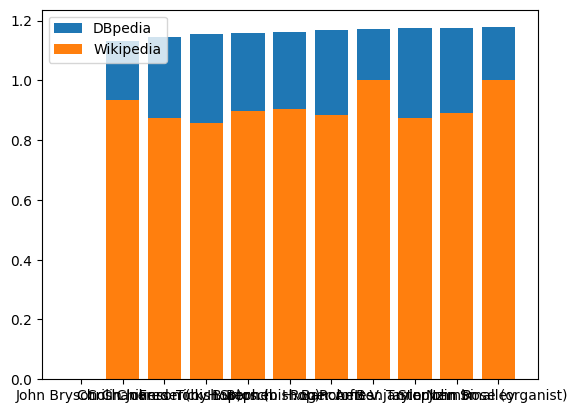

In [49]:
# NEarest ranking=distances
# ten_nndf is the dpedia data frame
# ten_nndf_wiki is the wikipedia data frame

plt.bar(ten_nndf['name'],ten_nndf['distances'],label='DBpedia')
plt.bar(ten_nndf_wiki['name'],ten_nndf_wiki['distances'],label='Wikipedia')
plt.legend()

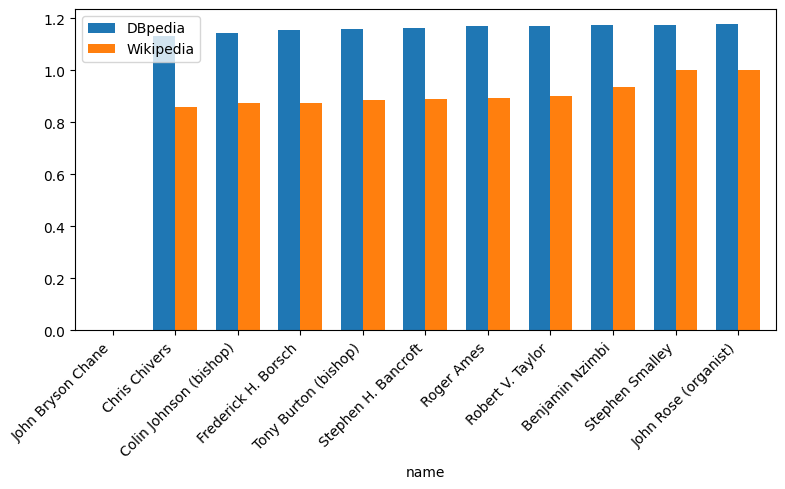

In [50]:
# Combine the two distance columns into one DataFrame
combined_df = pd.DataFrame({
    'DBpedia': ten_nndf['distances'].values,
    'Wikipedia': ten_nndf_wiki['distances'].values
}, index=ten_nndf['name'])

# Plotting via pandas automatically groups them
combined_df.plot(kind='bar', width=0.7, figsize=(8, 5))

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [51]:
print('DBpedia',ten_nndf['distances'].values)
print('Wikipedia',ten_nndf_wiki['distances'].values)

DBpedia [0.         1.1323916  1.14457298 1.15643428 1.15969597 1.16143514
 1.16986702 1.17232416 1.17518256 1.17645065 1.17747081]
Wikipedia [0.         0.85812569 0.87344565 0.87443095 0.88510545 0.89012514
 0.89589566 0.90288916 0.93541745 1.         1.00143262]


In [52]:
combined_df

,DBpedia,Wikipedia
name,,
John Bryson Chane,0.000000,0.000000
Chris Chivers,1.132392,0.858126
Colin Johnson (bishop),1.144573,0.873446
Frederick H. Borsch,1.156434,0.874431
Tony Burton (bishop),1.159696,0.885105
Stephen H. Bancroft,1.161435,0.890125
Roger Ames,1.169867,0.895896
Robert V. Taylor,1.172324,0.902889
Benjamin Nzimbi,1.175183,0.935417


### Part 3)


Make an interactive notebook where a user can choose or enter a name and the notebook displays the 10 closest individuals.

In addition to presenting the project slides, at the end of the presentation each student will demonstrate their code using a famous person suggested by the other students that exists in the DBpedia set.


In [53]:
from ipywidgets import interact

In [54]:
# who is index 29541?
@interact(Person_Index=(0,42786))
def multiply(Person_Index=29541):
  person=df.iloc[Person_Index]
  return(person)


interactive(children=(IntSlider(value=29541, description='Person_Index', max=42786), Output()), _dom_classes=(…

In [55]:
# 10 NN to person index
@interact(Person_Index=(0,42786))
def multiply(Person_Index=29541):
  nn = NearestNeighbors(n_neighbors=11)
  nn.fit(tf_idf)
  sent0 = tf_idf[Person_Index]
  distances, indices = nn.kneighbors(
  X = sent0,
  n_neighbors = 11,
  )
  names = [df['name'][idx] for idx in indices]
  ten_nndf_i=pd.DataFrame(names)

  ten_nndf_i=ten_nndf_i.transpose()

  ten_nndf_i['distances']=distances[0]

  return(ten_nndf_i)


interactive(children=(IntSlider(value=29541, description='Person_Index', max=42786), Output()), _dom_classes=(…

### Extras (don't use)

In [56]:
!curl -s https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv | wc -l

42786


In [57]:
%%bash
curl -s https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv |
head -1 |
tr , '\n' |
cat -n


     1	URI
     2	name
     3	text


In [58]:
%%bash
curl -s https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv |
head -2 |
tail -1 |
tr , '\n' |
cat -n


     1	<http://dbpedia.org/resource/Digby_Morrell>
     2	Digby Morrell
     3	digby morrell born 10 october 1979 is a former australian rules footballer who played with the kangaroos and carlton in the australian football league aflfrom western australia morrell played his early senior football for west perth his 44game senior career for the falcons spanned 19982000 and he was the clubs leading goalkicker in 2000 at the age of 21 morrell was recruited to the australian football league by the kangaroos football club with its third round selection in the 2001 afl rookie draft as a forward he twice kicked five goals during his time with the kangaroos the first was in a losing cause against sydney in 2002 and the other the following season in a drawn game against brisbaneafter the 2003 season morrell was traded along with david teague to the carlton football club in exchange for corey mckernan he played 32 games for the blues before being delisted at the end of 2005 he continued to play v